# Lab 1: Intro to Machine Learning

## Import Ionosphere dataset

In [3]:
from ucimlrepo import fetch_ucirepo

ionosphere = fetch_ucirepo(id=52)

X = ionosphere.data.features 
y = ionosphere.data.targets 
  
print(ionosphere.metadata) 
print(ionosphere.variables) 

{'uci_id': 52, 'name': 'Ionosphere', 'repository_url': 'https://archive.ics.uci.edu/dataset/52/ionosphere', 'data_url': 'https://archive.ics.uci.edu/static/public/52/data.csv', 'abstract': 'Classification of radar returns from the ionosphere', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 351, 'num_features': 34, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Sun Jan 01 1989', 'dataset_doi': '10.24432/C5W01B', 'creators': ['V. Sigillito', 'S. Wing', 'L. Hutton', 'K. Baker'], 'intro_paper': None, 'additional_info': {'summary': 'This radar data was collected by a system in Goose Bay, Labrador.  This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts.  See the paper for more details.  

## Prepare data to cross validation using KFold

In [4]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Train models

In [5]:
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
random_forest = RandomForestClassifier(max_depth=5, random_state=42)
logistic_regression = LogisticRegression(random_state=42)
support_vector_machine = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

multilayer_perceptron = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=500,
    random_state=42
)

classifiers: dict[str, BaseEstimator] = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Logistic Regression": logistic_regression,
    "Support Vector-Machine": support_vector_machine,
    "Multi-layer Perceptron": multilayer_perceptron,
}

scoring_metrics = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(
        precision_score, average="weighted", zero_division=0, pos_label=None
    ),
    "Recall": make_scorer(
        recall_score, average="weighted", zero_division=0, pos_label=None
    ),
    "F1": make_scorer(
        f1_score, average="weighted", zero_division=0, pos_label=None
    ),
}

for name, classifier in classifiers.items():
    print(f"Score for {name}")
    for metric_name, metric in scoring_metrics.items():
        scores = cross_val_score(classifier, X, y.values.ravel(), cv=kfold, scoring=metric)
        print(f"{metric_name}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")
    print()

Score for Decision Tree
Accuracy: Mean = 0.8974, Std = 0.0465
Precision: Mean = 0.8979, Std = 0.0469
Recall: Mean = 0.8974, Std = 0.0465
F1: Mean = 0.8959, Std = 0.0476

Score for Random Forest
Accuracy: Mean = 0.9316, Std = 0.0278
Precision: Mean = 0.9334, Std = 0.0284
Recall: Mean = 0.9316, Std = 0.0278
F1: Mean = 0.9308, Std = 0.0277

Score for Logistic Regression
Accuracy: Mean = 0.8773, Std = 0.0371
Precision: Mean = 0.8847, Std = 0.0354
Recall: Mean = 0.8773, Std = 0.0371
F1: Mean = 0.8721, Std = 0.0400

Score for Support Vector-Machine
Accuracy: Mean = 0.9373, Std = 0.0250
Precision: Mean = 0.9393, Std = 0.0242
Recall: Mean = 0.9373, Std = 0.0250
F1: Mean = 0.9362, Std = 0.0258

Score for Multi-layer Perceptron
Accuracy: Mean = 0.9344, Std = 0.0233
Precision: Mean = 0.9351, Std = 0.0235
Recall: Mean = 0.9344, Std = 0.0233
F1: Mean = 0.9336, Std = 0.0238



## Import Space dataset

In [6]:
import pandas as pd

df = pd.read_csv("space.csv") 
print(df)     

            x         y  label
0   -0.854800 -0.010376    0.0
1    0.355699 -0.519722    0.0
2    0.095440  0.777868    0.0
3    0.931966 -0.055718    0.0
4   -0.105374  0.987070    0.0
..        ...       ...    ...
893 -1.702515  1.549912    1.0
894 -1.033057  0.307836    1.0
895  1.761566  0.926185    1.0
896 -2.376760  0.449130    1.0
897 -1.712051 -0.699630    1.0

[898 rows x 3 columns]


## Train models 

In [7]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

trained_models = {}
for name, classifier in classifiers.items():
    classifier.fit(X, y)
    trained_models[name] = classifier
    print(f"{name}: wytrenowany")

Decision Tree: wytrenowany
Random Forest: wytrenowany
Logistic Regression: wytrenowany
Support Vector-Machine: wytrenowany
Multi-layer Perceptron: wytrenowany


## Draw results

/Users/kamil.rudny/Desktop/Personal/Knowledge-Engineering-and-Symbolic-ML/lab01-ml-intro/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kamil.rudny/Desktop/Personal/Knowledge-Engineering-and-Symbolic-ML/lab01-ml-intro/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/kamil.rudny/Desktop/Personal/Knowledge-Engineering-and-Symbolic-ML/lab01-ml-intro/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/kamil.rudny/Desktop/Personal/Knowledge-Engineering-and-Symbolic-ML/lab01-ml-intro/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: 

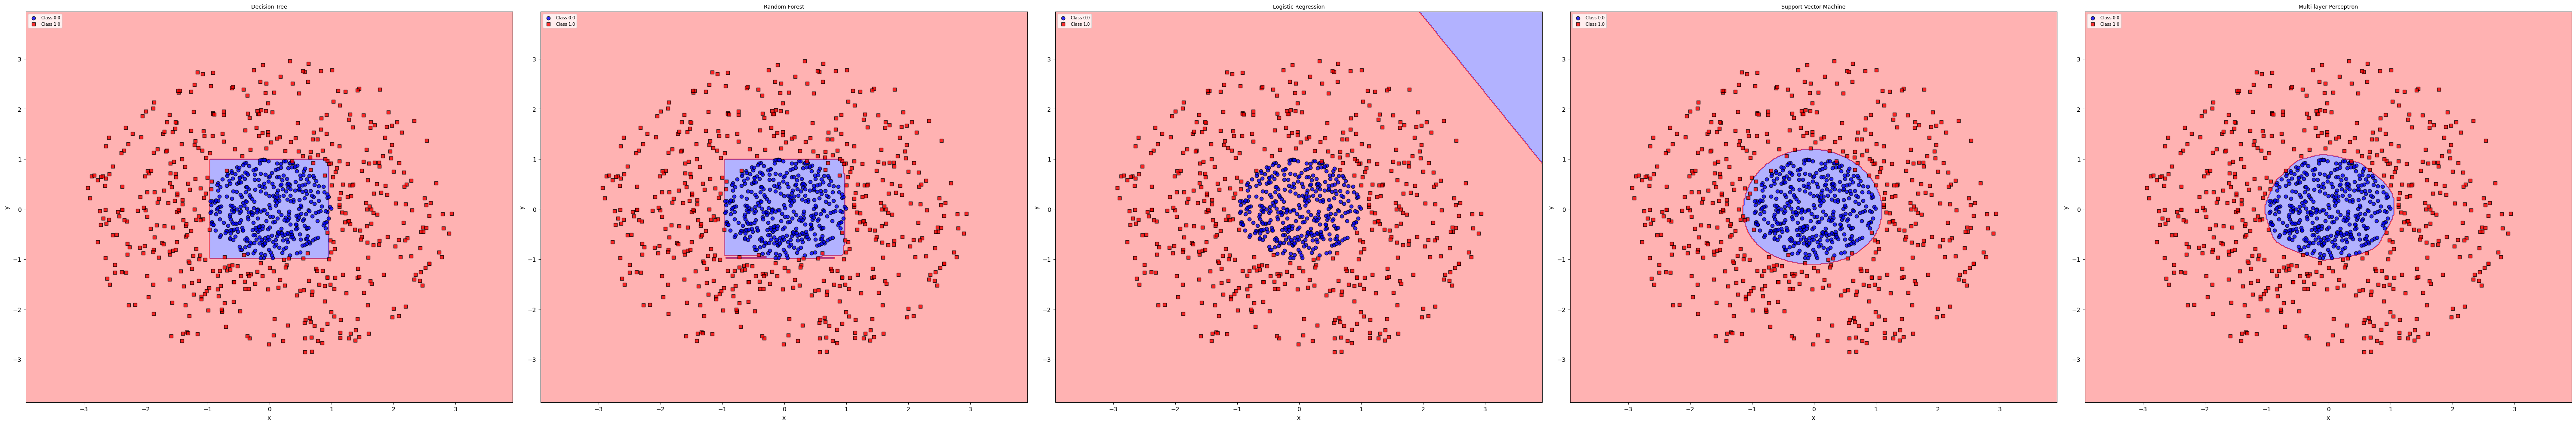

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ("o", "s", "^", "v", "<")
    colors = ("blue", "red", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    x2_min, x2_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        mask = y == cl
        plt.scatter(x=X[mask].iloc[:, 0], y=X[mask].iloc[:, 1],
                    alpha=0.8, c=colors[idx], marker=markers[idx],
                    label=f"Class {cl}", edgecolor="black")


fig, axes = plt.subplots(1, len(classifiers), figsize=(60, 10))

for ax, (name, classifier) in zip(axes, classifiers.items()):
    plt.sca(ax)
    plot_decision_regions(X, y, classifier)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()
